# Anime Score Prediction — Multiple Linear Regression Analysis

**Dataset:** MyAnimeList (MAL), pre-processed with one-hot encoded categorical
features (Type, Source, Rating, Genre, Studio).

Every decision below is made **after** looking at evidence generated in this
notebook, not asserted beforehand. In particular, Section 2 profiles *every*
numeric column for missingness, skew, and normality before anything is decided
about log transforms — the two variables that get log-transformed are picked
because they clear that screen, not because they were assumed to be the ones
that would.


**How to read this notebook:** Sections 1–9 build and select the model four different ways (p-value, AIC, BIC, Lasso) and they agree within 0.0013 Adj R². Section 12 finds real curvature in Duration and Episodes, which Section 14 folds back into a second selection pass. **Section 16 is the final, reportable model** (51 predictors, Adj R² = 0.6386, HC3-robust SEs). Section 13 is kept only as a record of the first-pass model, not the final result.


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

FILE_PATH = "animesscoreprediction.xlsx"   # <-- update to your file path
SHEET_NAME = "Data"
pd.set_option("display.max_rows", 150)

## 1. Load data

Only rows with a known `Score` are usable for training — that's the modeling
sample everything downstream is built on.

In [2]:
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)
keep = df["Score"].notna()
d = df.loc[keep].copy()
print(f"Rows with a known Score: {len(d)} of {len(df)}")

Rows with a known Score: 15692 of 24878


## 2. Data profiling — every column, before any decisions

Rather than deciding upfront which columns are "the skewed ones," every
numeric column is profiled here: missingness, skew (raw and log-transformed),
and a normality test. Binary one-hot columns (`Type_*`, `Genre_*`, `Source_*`,
`Rating_*`, `Studio_*`) are profiled separately from continuous ones — skew
and normality mean something different for a 0/1 indicator than for a count
or scale variable, so lumping them together would just produce noise.

In [3]:
numeric_cols = d.select_dtypes(include=[np.number]).columns.tolist()

binary_cols, continuous_cols = [], []
for c in numeric_cols:
    vals = pd.unique(d[c].dropna())
    is_binary = len(vals) <= 2 and set(np.round(vals.astype(float), 6)).issubset({0.0, 1.0})
    (binary_cols if is_binary else continuous_cols).append(c)

# Columns that are >95% empty are almost certainly leftover export junk,
# not real data -- flag them explicitly rather than silently profiling noise.
empty_junk = [c for c in continuous_cols + binary_cols if d[c].isna().mean() > 0.95]
continuous_cols = [c for c in continuous_cols if c not in empty_junk]
binary_cols = [c for c in binary_cols if c not in empty_junk]

print(f"{len(numeric_cols)} numeric columns total")
print(f"  -> {len(continuous_cols)} continuous")
print(f"  -> {len(binary_cols)} binary / one-hot")
print(f"  -> {len(empty_junk)} are >95% empty (junk export columns) -- excluded from profiling below")
print("\nSample of junk columns (should be deleted from the source file):", empty_junk[:5], "...")

71 numeric columns total
  -> 10 continuous
  -> 61 binary / one-hot
  -> 0 are >95% empty (junk export columns) -- excluded from profiling below

Sample of junk columns (should be deleted from the source file): [] ...


### 2.1 Continuous columns — missingness, skew, normality

For each continuous column: raw skew, skew after a log transform (using
`log1p` when the column contains zeros, since plain `log(0)` is undefined —
and skipped entirely if it contains negatives, since neither works), and a
Jarque–Bera normality test.

**One honest caveat on the normality test**: with n≈15,000+, a Jarque–Bera
(or any normality) test has enormous statistical power — it will report a
significant departure from normality for almost any real variable, including
ones that are practically close to normal. The *p-value* here is not treated
as a meaningful pass/fail; the skew numbers are what actually drive decisions
below.

In [4]:
rows = []
for c in continuous_cols:
    valid = d[c].dropna()
    pct_missing = 100 * d[c].isna().mean()
    has_neg = (valid < 0).any()
    has_zero = (valid == 0).any()
    if len(valid) < 8:
        rows.append(dict(Column=c, PctMissing=round(pct_missing, 2), Nvalid=len(valid),
                          SkewRaw=np.nan, SkewLog=np.nan, JB_stat=np.nan, Note="too few values"))
        continue
    if has_neg:
        skew_log, note = np.nan, "has negatives, log N/A"
    elif has_zero:
        skew_log, note = np.log1p(valid).skew(), "has zeros, used log1p"
    else:
        skew_log, note = np.log(valid).skew(), ""
    jb_stat, jb_p = stats.jarque_bera(valid)
    rows.append(dict(Column=c, PctMissing=round(pct_missing, 2), Nvalid=len(valid),
                      SkewRaw=round(valid.skew(), 2),
                      SkewLog=round(skew_log, 2) if not np.isnan(skew_log) else None,
                      JB_stat=round(jb_stat, 1), Note=note))

continuous_profile = pd.DataFrame(rows).sort_values("SkewRaw", key=abs, ascending=False)
continuous_profile

,Column,PctMissing,Nvalid,SkewRaw,SkewLog,JB_stat,Note
1,Episodes,0.56,15604,32.63,0.73,1.487081e+09,
7,Favorites,0.00,15692,21.49,0.95,2.651373e+08,"has zeros, used log1p"
8,Scored By,0.00,15692,9.20,0.58,9.232014e+06,
2,Airing Duration (days),50.34,7793,8.86,-0.16,5.774820e+06,
9,Members,0.00,15692,7.55,0.50,4.165560e+06,
3,Premier Year,0.05,15684,-2.11,-2.15,4.170680e+04,
5,Duration (min),0.10,15677,2.02,-0.53,2.280340e+04,"has zeros, used log1p"
4,Ending Year,50.27,7804,-1.22,-1.24,2.553600e+03,
6,Popularity,0.00,15692,0.14,-1.91,7.490000e+02,
0,Score,0.00,15692,-0.12,-0.71,3.780000e+01,


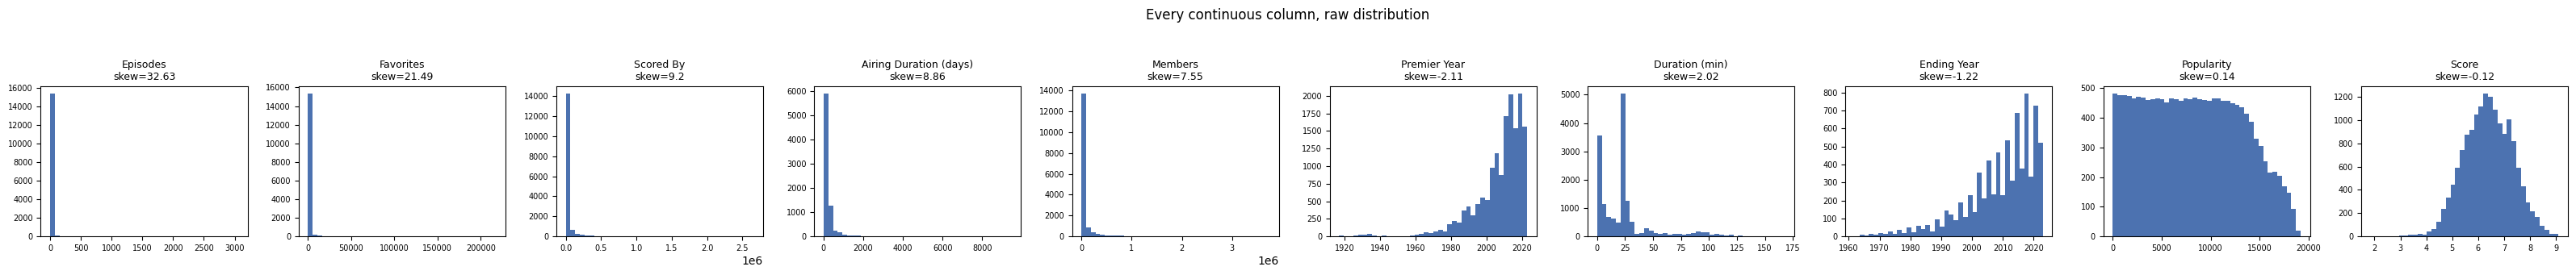

In [5]:
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(3.2*len(continuous_cols), 3.2))
for ax, c in zip(axes, continuous_profile["Column"]):
    ax.hist(d[c].dropna(), bins=40, color="#4C72B0")
    skew_val = continuous_profile.loc[continuous_profile.Column == c, "SkewRaw"].values[0]
    ax.set_title(f"{c}\nskew={skew_val}", fontsize=9)
    ax.tick_params(labelsize=7)
fig.suptitle("Every continuous column, raw distribution", y=1.05)
fig.tight_layout()
fig.savefig("chart0_all_continuous_raw.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.2 Binary / one-hot columns — missingness and rare categories

Skew isn't the relevant question for a 0/1 indicator. What matters instead:
is the column almost entirely empty, and is it so rare (or so common) that a
regression coefficient on it would be estimated from a handful of rows and be
essentially noise?

In [6]:
rows = []
for c in binary_cols:
    col = d[c]
    rows.append(dict(
        Column=c,
        PctMissing=round(100 * col.isna().mean(), 2),
        NOnes=int(col.sum()),
        PctOnes=round(100 * col.mean(), 3),
    ))
binary_profile = pd.DataFrame(rows).sort_values("NOnes")

print("Rarest one-hot columns (fewest positive cases):")
display(binary_profile.head(15))

near_constant = binary_profile[binary_profile["NOnes"] < 10]
print(f"\n{len(near_constant)} columns have fewer than 10 positive cases in the modeling sample "
      f"-- any coefficient on these would be estimated from almost no data:")
display(near_constant)

Rarest one-hot columns (fewest positive cases):


,Column,PctMissing,NOnes,PctOnes
6,Status_Currently Airing,0.0,0,0.000
7,Status_Not yet aired,0.0,0,0.000
5,Type_null,0.0,1,0.006
57,Studio_Shanghai Animation Film Studio,0.0,7,0.045
22,Source_Radio,0.0,10,0.064
15,Source_Web novel,0.0,42,0.268
38,Genre_Erotica,0.0,43,0.274
19,Source_Picture book,0.0,55,0.350
20,Source_Card game,0.0,65,0.414
17,Source_Book,0.0,91,0.580



4 columns have fewer than 10 positive cases in the modeling sample -- any coefficient on these would be estimated from almost no data:


,Column,PctMissing,NOnes,PctOnes
6,Status_Currently Airing,0.0,0,0.000
7,Status_Not yet aired,0.0,0,0.000
5,Type_null,0.0,1,0.006
57,Studio_Shanghai Animation Film Studio,0.0,7,0.045


**What this explains, concretely:**
- `Status_Currently Airing` and `Status_Not yet aired` have **zero** positive cases here — which makes sense, since a title needs to have finished airing (or at least accumulated ratings) to have a Score at all. That's *why* these were never candidate predictors, not an oversight.
- `Studio_Shanghai Animation Film Studio` (7 cases) and `Type_null` (1 case) are similarly why the model only includes individually-dummied studios above a minimum production count, rather than every studio in the dataset — anything this rare can't support a stable coefficient.
- `Source_Radio` turns out to have only 10 positive cases — which is exactly why it's combined with `Source_Other` into a single column later in this notebook, rather than kept as its own predictor.

### 2.3 Basic cleanliness checks

In [7]:
print("Exact duplicate rows:", d.duplicated().sum())
print("Duplicate Display Names:", d['Display Name'].duplicated().sum(), "(may be legitimate re-releases/remakes, not necessarily errors)")
print("Negative values found in any continuous column:",
      {c: int((d[c].dropna() < 0).sum()) for c in continuous_cols if (d[c].dropna() < 0).any()} or "none")

Exact duplicate rows: 0
Duplicate Display Names: 46 (may be legitimate re-releases/remakes, not necessarily errors)
Negative values found in any continuous column: none


### 2.4 So which continuous columns actually get log-transformed?

Applying one consistent rule to every continuous column: flag it if raw skew
exceeds 1 in magnitude *and* a log-family transform is technically valid.

In [8]:
candidates = continuous_profile[
    (continuous_profile["SkewRaw"].abs() > 1) & (continuous_profile["SkewLog"].notna())
].copy()
candidates["SkewImproved"] = candidates["SkewLog"].abs() < candidates["SkewRaw"].abs()
candidates[["Column", "SkewRaw", "SkewLog", "SkewImproved", "Note"]]

,Column,SkewRaw,SkewLog,SkewImproved,Note
1,Episodes,32.63,0.73,True,
7,Favorites,21.49,0.95,True,"has zeros, used log1p"
8,Scored By,9.20,0.58,True,
2,Airing Duration (days),8.86,-0.16,True,
9,Members,7.55,0.50,True,
3,Premier Year,-2.11,-2.15,False,
5,Duration (min),2.02,-0.53,True,"has zeros, used log1p"
4,Ending Year,-1.22,-1.24,False,


Reading the result column by column:

- **Episodes** (32.63 → 0.73) and **Members** (7.55 → 0.50) clear the bar by a wide margin — these get log-transformed as model predictors below.
- **Favorites** (21.49 → 0.95) and **Scored By** (9.20 → 0.58) *also* clear the bar and would benefit from log1p/log — but neither becomes a model predictor at all, for the separate collinearity/leakage reasons covered in Section 4. Skew isn't the reason they're excluded; it's mentioned here only because the profiling naturally surfaces it.
- **Duration (min)** raw skew is 2.02 — technically above the threshold, with `log1p` nominally reducing it to −0.53. Rather than assume this means Duration should be logged too, it's worth actually testing:

In [9]:
ep_full = df["Episodes"].fillna(df["Episodes"].median())
dur_full = pd.to_numeric(df["Duration (min)"], errors="coerce")
dur_full = dur_full.fillna(dur_full.median())
yr_full = df["Premier Year"].fillna(df["Premier Year"].median()) - 2000

ep = ep_full.loc[keep].values
dur_raw = dur_full.loc[keep].values
dur_log1p = np.log1p(dur_raw)
yr = yr_full.loc[keep].values
members = d["Members"].values
y = d["Score"].values.astype(float)

# Compare raw vs. log1p Duration head-to-head, holding everything else fixed
X_raw = sm.add_constant(np.column_stack([np.log(ep), dur_raw, yr, np.log(members)]))
X_log = sm.add_constant(np.column_stack([np.log(ep), dur_log1p, yr, np.log(members)]))
m_raw = sm.OLS(y, X_raw).fit()
m_log = sm.OLS(y, X_log).fit()

print(f"Raw Duration:    R2={m_raw.rsquared:.5f}  AdjR2={m_raw.rsquared_adj:.5f}  t={m_raw.tvalues[2]:.2f}")
print(f"log1p(Duration): R2={m_log.rsquared:.5f}  AdjR2={m_log.rsquared_adj:.5f}  t={m_log.tvalues[2]:.2f}")
print(f"\n{'Raw Duration fits marginally better' if m_raw.rsquared > m_log.rsquared else 'log1p(Duration) fits better'} "
      f"-- the difference is {abs(m_raw.rsquared - m_log.rsquared):.5f} in R2, not practically meaningful either way.")

Raw Duration:    R2=0.54631  AdjR2=0.54620  t=35.61
log1p(Duration): R2=0.54573  AdjR2=0.54561  t=35.31

Raw Duration fits marginally better -- the difference is 0.00058 in R2, not practically meaningful either way.


**Conclusion: Duration is kept on its raw scale.** This is the actual point of
profiling every column instead of applying one rule blindly — a skew screen is
a useful first pass, but the real test is whether the transform improves the
model, and here it measurably does not. Episodes and Members are transformed
because both the skew screen *and* the fit improvement support it; Duration
clears only the first bar, not the second, so it's left alone.

**Premier Year** (skew −2.11) isn't a log-transform candidate at all for a
different reason: it's a calendar year, not a count or multiplicative
process, so a log transform doesn't have a sensible interpretation regardless
of the skew number — and for what it's worth, logging it barely changes the
skew anyway (−2.11 → −2.15). It's recentered (`year − 2000`) later instead,
which is the appropriate fix for a variable that's just shifted, not skewed
in the multiplicative sense.

**Ending Year** and **Airing Duration (days)** are both roughly 50% missing
(titles still airing have no end date yet) — that's a missingness problem,
not a skew problem, and it's *why* neither is used as a predictor at all,
independent of their skew values.

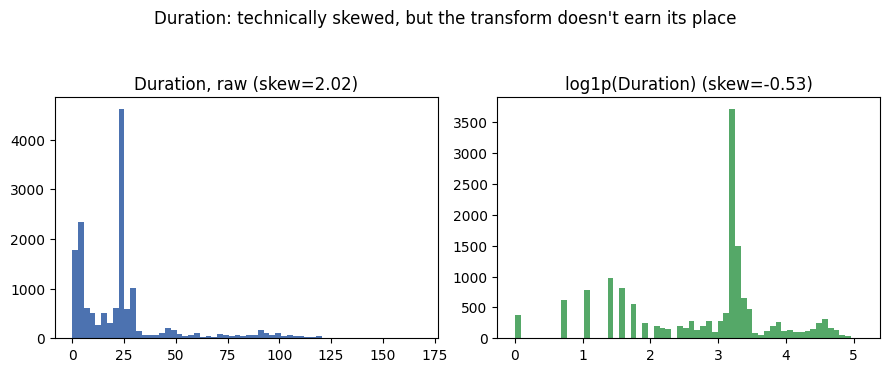

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].hist(dur_raw, bins=60, color="#4C72B0")
axes[0].set_title(f"Duration, raw (skew={pd.Series(dur_raw).skew():.2f})")
axes[1].hist(dur_log1p, bins=60, color="#55A868")
axes[1].set_title(f"log1p(Duration) (skew={pd.Series(dur_log1p).skew():.2f})")
fig.suptitle("Duration: technically skewed, but the transform doesn't earn its place", y=1.05)
fig.tight_layout()
fig.savefig("chart0b_duration_check.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Feature engineering (final)

Episodes and Members are log-transformed, per Section 2.4. This also
compresses the leverage of extreme outliers (a few very long-running or
mega-popular titles) under OLS's squared-error loss, and turns the
coefficient into a "percent change in X → point change in Score"
semi-elasticity — a more natural read across variables spanning several
orders of magnitude than a flat per-unit effect.

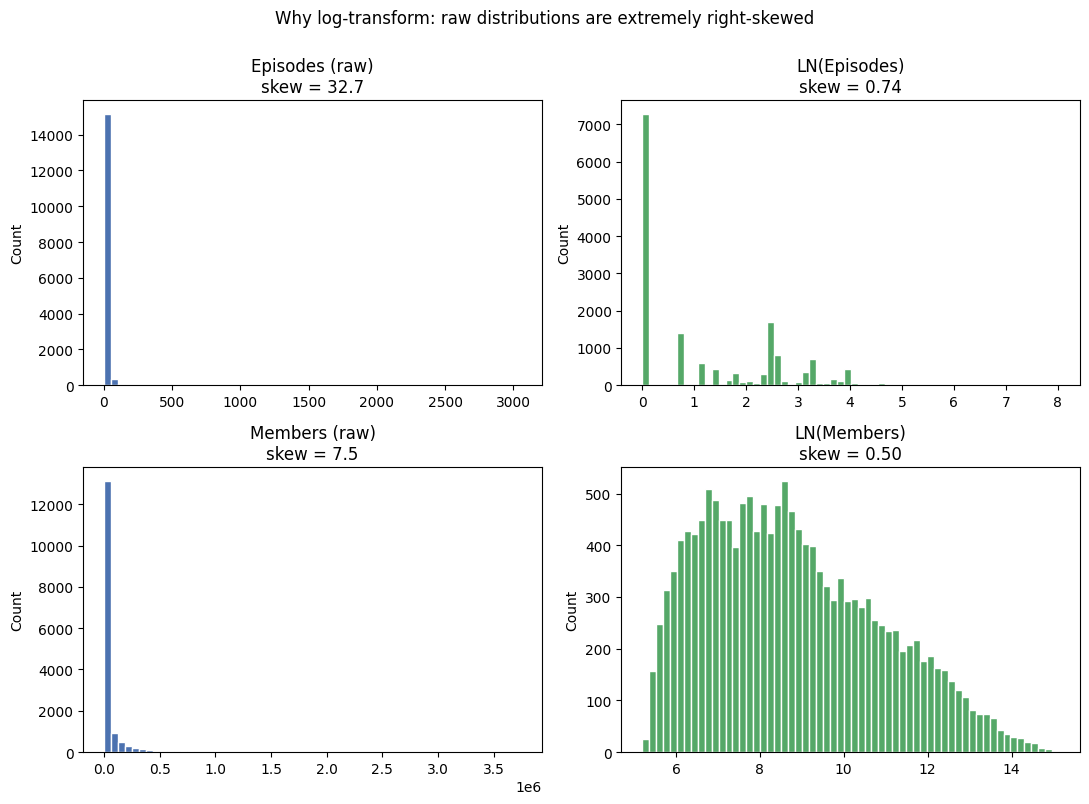

In [11]:
ep = ep_full.loc[keep].values
dur = dur_full.loc[keep].values   # kept raw, per the test above
yr = yr_full.loc[keep].values
members = d["Members"].values

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].hist(ep, bins=60, color="#4C72B0", edgecolor="white")
axes[0, 0].set_title(f"Episodes (raw)\nskew = {pd.Series(ep).skew():.1f}")
axes[0, 1].hist(np.log(ep), bins=60, color="#55A868", edgecolor="white")
axes[0, 1].set_title(f"LN(Episodes)\nskew = {pd.Series(np.log(ep)).skew():.2f}")
axes[1, 0].hist(members, bins=60, color="#4C72B0", edgecolor="white")
axes[1, 0].set_title(f"Members (raw)\nskew = {pd.Series(members).skew():.1f}")
axes[1, 1].hist(np.log(members), bins=60, color="#55A868", edgecolor="white")
axes[1, 1].set_title(f"LN(Members)\nskew = {pd.Series(np.log(members)).skew():.2f}")
for ax in axes.flat:
    ax.set_ylabel("Count")
fig.suptitle("Why log-transform: raw distributions are extremely right-skewed", y=1.00)
fig.tight_layout()
fig.savefig("chart1_skew_fix.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Why Popularity, Favorites, and Scored By are excluded

Four columns describe audience engagement: Popularity, Favorites, Scored By,
and Members. Only Members is used as a predictor — here's the evidence for
excluding the other three.

Engagement-cluster correlation matrix (raw scale):


,Popularity,Favorites,Scored By,Members,Score
Popularity,1.000,-0.197,-0.377,-0.430,-0.698
Favorites,-0.197,1.000,0.785,0.774,0.235
Scored By,-0.377,0.785,1.000,0.989,0.351
Members,-0.430,0.774,0.989,1.000,0.391
Score,-0.698,0.235,0.351,0.391,1.000


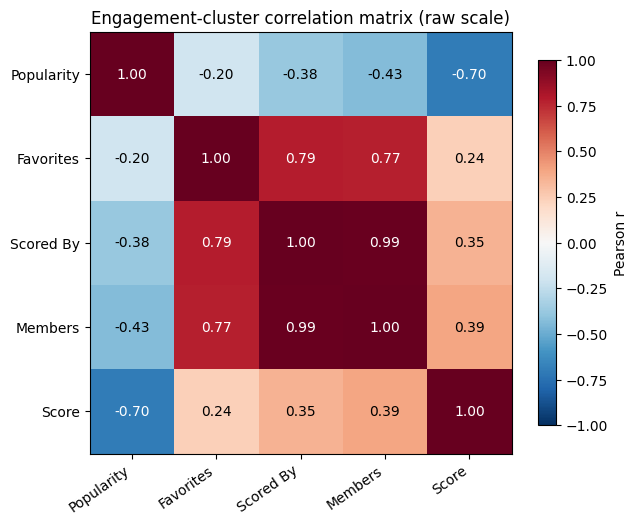

In [12]:
engagement = d[["Popularity", "Favorites", "Scored By", "Members", "Score"]]
eng_corr = engagement.corr()
print("Engagement-cluster correlation matrix (raw scale):")
display(eng_corr.round(3))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(eng_corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(eng_corr.columns))); ax.set_xticklabels(eng_corr.columns, rotation=35, ha="right")
ax.set_yticks(range(len(eng_corr.columns))); ax.set_yticklabels(eng_corr.columns)
for i in range(len(eng_corr)):
    for j in range(len(eng_corr)):
        val = eng_corr.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="white" if abs(val) > 0.6 else "black")
ax.set_title("Engagement-cluster correlation matrix (raw scale)")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
fig.tight_layout()
fig.savefig("chart2_engagement_corr.png", dpi=150, bbox_inches="tight")
plt.show()

Scored By and Members correlate at 0.99 — not two independent signals, effectively the same one measured twice. There's also a conceptual reverse-causality risk: Popularity is a MAL-computed rank entangled with Score itself, so including it risks predicting Score partly with a consequence of Score. The quantified cost of adding all three back in anyway is measured directly in Section 6b, once the final model exists to test it against.

## 5. Build the full 60-predictor design matrix

In [13]:
type_cols = ["Type_Special", "Type_Movie", "Type_OVA", "Type_ONA", "Type_Music"]
source_TtoAA = ["Source_Visual novel", "Source_Novel", "Source_Original", "Source_Light novel",
                "Source_4-koma manga", "Source_Web manga", "Source_Game", "Source_Web novel"]
source_other_radio = d["Source_Other"].values + d["Source_Radio"].values
source_ACtoAG = ["Source_Book", "Source_Mixed media", "Source_Picture book", "Source_Card game", "Source_Music"]
rating_cols = ["Rating_PG-13 - Teens 13 or older", "Rating_R+ - Mild Nudity", "Rating_PG - Children",
               "Rating_G - All Ages", "Rating_Rx - Hentai", "Rating_null"]
genre_cols = ["Genre_Action", "Genre_Adventure", "Genre_Avant Garde", "Genre_Award Winning",
              "Genre_Boys Love", "Genre_Comedy", "Genre_Drama", "Genre_Ecchi", "Genre_Erotica",
              "Genre_Fantasy", "Genre_Girls Love", "Genre_Gourmet", "Genre_Hentai", "Genre_Horror",
              "Genre_Mystery", "Genre_Romance", "Genre_Sci-Fi", "Genre_Slice of Life", "Genre_Sports",
              "Genre_Supernatural", "Genre_Suspense"]
studio_BKtoBP = ["Studio_Toei Animation", "Studio_Sunrise", "Studio_J.C.Staff", "Studio_Madhouse",
                  "Studio_Production I.G", "Studio_TMS Entertainment"]
studio_BRtoBT = ["Studio_Studio Deen", "Studio_OLM", "Studio_Pierrot"]

cols_order = (["LN(Episodes)", "Duration (min)", "Year (since 2000)", "LN(Members)"]
              + type_cols + source_TtoAA + ["Source_Other+Radio"] + source_ACtoAG + ["Source_null"]
              + rating_cols + genre_cols + studio_BKtoBP + studio_BRtoBT)

X_parts = [np.log(ep), dur, yr, np.log(members)]
for c in type_cols: X_parts.append(d[c].values)
for c in source_TtoAA: X_parts.append(d[c].values)
X_parts.append(source_other_radio)
for c in source_ACtoAG: X_parts.append(d[c].values)
X_parts.append(d["Source_null"].values)
for c in rating_cols: X_parts.append(d[c].values)
for c in genre_cols: X_parts.append(d[c].values)
for c in studio_BKtoBP: X_parts.append(d[c].values)
for c in studio_BRtoBT: X_parts.append(d[c].values)

X = np.column_stack(X_parts).astype(float)
print(f"Design matrix: {X.shape[0]} rows x {X.shape[1]} predictors")

def fit_ols(idx):
    Xc = sm.add_constant(X[:, idx]) if len(idx) else np.ones((X.shape[0], 1))
    return sm.OLS(y, Xc).fit()

Design matrix: 15692 rows x 60 predictors


## 6. Baseline model — all 60 predictors

In [14]:
full_idx = list(range(len(cols_order)))
model_full = fit_ols(full_idx)
print(f"Full model (60 predictors): R2={model_full.rsquared:.4f}  AdjR2={model_full.rsquared_adj:.4f}  "
      f"F={model_full.fvalue:.2f}  n={int(model_full.nobs)}")

Full model (60 predictors): R2=0.6332  AdjR2=0.6318  F=449.71  n=15692


## 7. Backward elimination on significance (p < 0.05)

True backward elimination is iterative: drop the single worst predictor,
refit, recheck significance, repeat until everything remaining clears the
threshold — not a one-shot drop of everything that looked insignificant in
the first fit.

In [15]:
def backward_elimination_pvalue(idx, alpha=0.05):
    idx = list(idx)
    while True:
        model = fit_ols(idx)
        pvals = model.pvalues[1:]
        worst_i = int(np.argmax(pvals))
        if pvals[worst_i] > alpha:
            idx.pop(worst_i)
        else:
            return idx, model

sig_idx, model_sig = backward_elimination_pvalue(full_idx)
print(f"Significance-based model ({len(sig_idx)} predictors): "
      f"R2={model_sig.rsquared:.4f}  AdjR2={model_sig.rsquared_adj:.4f}  F={model_sig.fvalue:.2f}")
dropped_sig = sorted(set(cols_order[i] for i in full_idx) - set(cols_order[i] for i in sig_idx))
print("Dropped:", dropped_sig)

max_p_remaining = model_sig.pvalues[1:].max()
print(f"\nLargest remaining p-value: {max_p_remaining:.4g} "
      f"({'converged cleanly' if max_p_remaining < 0.05 else 'CHECK -- should be < 0.05'})")

Significance-based model (48 predictors): R2=0.6329  AdjR2=0.6318  F=561.81
Dropped: ['Genre_Fantasy', 'Genre_Gourmet', 'Genre_Romance', 'Genre_Sci-Fi', 'Genre_Suspense', 'Rating_Rx - Hentai', 'Rating_null', 'Source_Book', 'Source_Novel', 'Source_Picture book', 'Studio_J.C.Staff', 'Studio_OLM']

Largest remaining p-value: 0.04097 (converged cleanly)


## 7b. Quantifying the cost of adding the engagement cluster back in

The other half of Section 4's claim: adding Popularity, Favorites, and Scored
By (log-transformed) to the *final* model raises fit, but destabilizes
LN(Members), which is already in the model.

Adjusted R2 without cluster: 0.6318
Adjusted R2 with cluster:    0.6730
VIF of LN(Members) without / with: 2.47 / 84.23
t-stat of LN(Members) without / with: 82.35 / 1.10 (no longer significant)


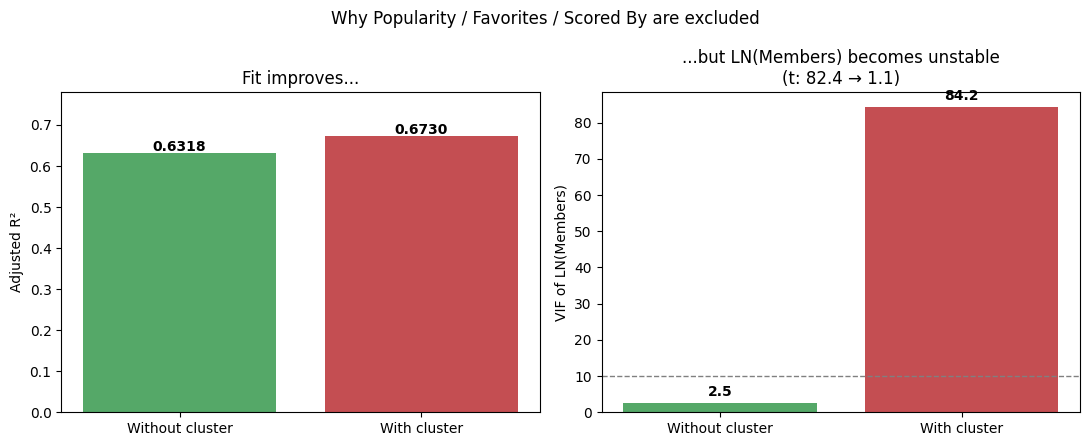

In [16]:
X_sig = X[:, sig_idx]
model_sig_only = sm.OLS(y, sm.add_constant(X_sig)).fit()

extra = np.column_stack([
    np.log(d["Popularity"].values),
    np.log(d["Favorites"].values + 1),
    np.log(d["Scored By"].values),
])
Xc_ext = sm.add_constant(np.column_stack([X_sig, extra]))
model_ext = sm.OLS(y, Xc_ext).fit()

members_pos = [j for j, i in enumerate(sig_idx) if cols_order[i] == "LN(Members)"][0]
vif_members_without = variance_inflation_factor(sm.add_constant(X_sig), members_pos + 1)
vif_members_with = variance_inflation_factor(Xc_ext, members_pos + 1)
t_members_without = model_sig_only.tvalues[members_pos + 1]
t_members_with = model_ext.tvalues[members_pos + 1]

print(f"Adjusted R2 without cluster: {model_sig_only.rsquared_adj:.4f}")
print(f"Adjusted R2 with cluster:    {model_ext.rsquared_adj:.4f}")
print(f"VIF of LN(Members) without / with: {vif_members_without:.2f} / {vif_members_with:.2f}")
print(f"t-stat of LN(Members) without / with: {t_members_without:.2f} / {t_members_with:.2f} "
      f"({'no longer significant' if abs(t_members_with) < 1.96 else 'still significant'})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
bars = axes[0].bar(["Without cluster", "With cluster"],
                    [model_sig_only.rsquared_adj, model_ext.rsquared_adj], color=["#55A868", "#C44E52"])
for b, v in zip(bars, [model_sig_only.rsquared_adj, model_ext.rsquared_adj]):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.4f}", ha="center", fontweight="bold")
axes[0].set_ylim(0, 0.78); axes[0].set_ylabel("Adjusted R²"); axes[0].set_title("Fit improves...")

bars2 = axes[1].bar(["Without cluster", "With cluster"],
                     [vif_members_without, vif_members_with], color=["#55A868", "#C44E52"])
for b, v in zip(bars2, [vif_members_without, vif_members_with]):
    axes[1].text(b.get_x()+b.get_width()/2, v+2, f"{v:.1f}", ha="center", fontweight="bold")
axes[1].axhline(10, color="gray", linestyle="--", linewidth=1)
axes[1].set_ylabel("VIF of LN(Members)")
axes[1].set_title(f"...but LN(Members) becomes unstable\n(t: {t_members_without:.1f} \u2192 {t_members_with:.1f})")
fig.suptitle("Why Popularity / Favorites / Scored By are excluded")
fig.tight_layout()
fig.savefig("chart3_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Stepwise selection on information criteria (AIC / BIC)

AIC's implicit bar for keeping a variable is roughly p ~ 0.16 (more lenient
than 0.05); BIC penalizes each parameter by log(n) — a much harsher tax at
n=15,692. Running both directions checks the result isn't an artifact of
search direction.

In [17]:
def forward_selection(criterion="aic"):
    selected, remaining = [], list(range(len(cols_order)))
    cur_score = getattr(fit_ols(selected), criterion)
    while remaining:
        scored = [(getattr(fit_ols(selected + [c]), criterion), c) for c in remaining]
        best_score, best_c = min(scored)
        if best_score < cur_score - 1e-9:
            selected.append(best_c); remaining.remove(best_c); cur_score = best_score
        else:
            break
    return selected, cur_score

def backward_elimination_ic(criterion="aic"):
    selected = list(range(len(cols_order)))
    cur_score = getattr(fit_ols(selected), criterion)
    improved = True
    while improved and len(selected) > 1:
        scored = [(getattr(fit_ols([c for c in selected if c != cand]), criterion), cand) for cand in selected]
        best_score, best_c = min(scored)
        if best_score < cur_score - 1e-9:
            selected.remove(best_c); cur_score = best_score
        else:
            improved = False
    return selected, cur_score

fwd_aic_idx, fwd_aic_score = forward_selection("aic")
bwd_aic_idx, bwd_aic_score = backward_elimination_ic("aic")
bwd_bic_idx, bwd_bic_score = backward_elimination_ic("bic")

print(f"Forward AIC  ({len(fwd_aic_idx)} predictors): AIC={fwd_aic_score:.1f}")
print(f"Backward AIC ({len(bwd_aic_idx)} predictors): AIC={bwd_aic_score:.1f}")
print(f"Backward BIC ({len(bwd_bic_idx)} predictors): BIC={bwd_bic_score:.1f}")
print("Forward and backward AIC agree on the same set:", set(fwd_aic_idx) == set(bwd_aic_idx))

Forward AIC  (50 predictors): AIC=26580.6
Backward AIC (50 predictors): AIC=26580.6
Backward BIC (40 predictors): BIC=26940.8
Forward and backward AIC agree on the same set: True


## 9. Model comparison — is the final set actually defensible?

,Method,# Predictors,Adj R2
0,"Backward, p<0.05",48,0.6318
1,"Forward, AIC",50,0.6319
2,"Backward, AIC",50,0.6319
3,"Backward, BIC",40,0.6305


Spread in Adjusted R2 across all 4 methods: 0.0013


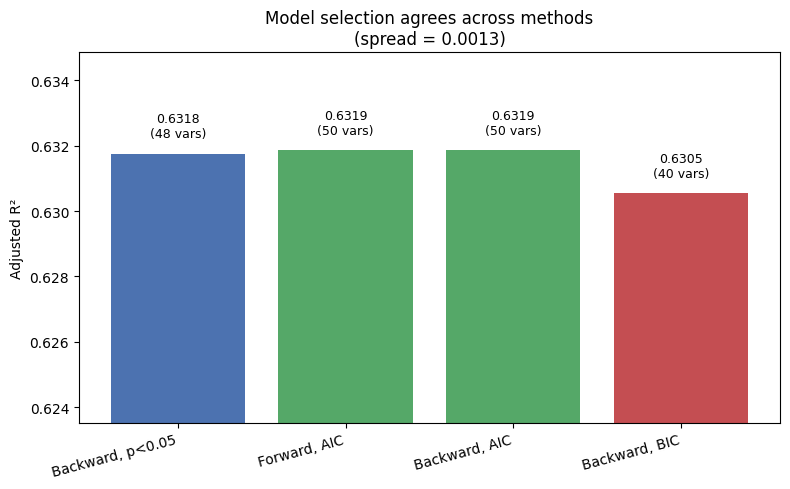

In [18]:
comparison = pd.DataFrame({
    "Method": ["Backward, p<0.05", "Forward, AIC", "Backward, AIC", "Backward, BIC"],
    "# Predictors": [len(sig_idx), len(fwd_aic_idx), len(bwd_aic_idx), len(bwd_bic_idx)],
    "Adj R2": [fit_ols(sig_idx).rsquared_adj, fit_ols(fwd_aic_idx).rsquared_adj,
               fit_ols(bwd_aic_idx).rsquared_adj, fit_ols(bwd_bic_idx).rsquared_adj],
})
display(comparison.round(4))
spread = comparison["Adj R2"].max() - comparison["Adj R2"].min()
print(f"Spread in Adjusted R2 across all 4 methods: {spread:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#4C72B0", "#55A868", "#55A868", "#C44E52"]
bars = ax.bar(comparison["Method"], comparison["Adj R2"], color=colors)
for b, (_, row) in zip(bars, comparison.iterrows()):
    ax.text(b.get_x()+b.get_width()/2, row["Adj R2"]+0.0005, f"{row['Adj R2']:.4f}\n({row['# Predictors']} vars)",
            ha="center", fontsize=9)
ax.set_ylim(comparison["Adj R2"].min()-0.007, comparison["Adj R2"].max()+0.003)
ax.set_ylabel("Adjusted R²"); ax.set_title(f"Model selection agrees across methods\n(spread = {spread:.4f})")
plt.xticks(rotation=15, ha="right")
fig.tight_layout()
fig.savefig("chart4_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Lasso regression — regularization-based selection

Stepwise (p-value, AIC, BIC) and Lasso answer the same question two different
ways. Stepwise does hard in/out decisions one variable at a time; Lasso
shrinks all 60 coefficients simultaneously and pushes the least useful ones
to exactly zero, with the amount of shrinkage (alpha) chosen by
cross-validation rather than a fixed p-value or IC penalty. Lasso needs
standardized predictors -- unlike OLS, the penalty is on the raw coefficient
size, so unscaled variables (e.g. Duration in minutes vs. a 0/1 genre flag)
would get penalized unevenly.

In [19]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso_cv = LassoCV(cv=5, n_alphas=100, max_iter=20000, random_state=42, n_jobs=-1)
lasso_cv.fit(X_scaled, y)

lasso_idx = [i for i, coef in enumerate(lasso_cv.coef_) if coef != 0]

print(f"Chosen alpha (via 5-fold CV): {lasso_cv.alpha_:.5f}")
print(f"Predictors kept: {len(lasso_idx)} of {len(cols_order)}")
print(f"Predictors dropped: {sorted(set(cols_order) - set(cols_order[i] for i in lasso_idx))}")

c:\Users\21650\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1613: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


Chosen alpha (via 5-fold CV): 0.00230
Predictors kept: 53 of 60
Predictors dropped: ['Genre_Fantasy', 'Genre_Gourmet', 'Genre_Sci-Fi', 'Genre_Suspense', 'Rating_Rx - Hentai', 'Source_Novel', 'Studio_J.C.Staff']


,Method,# Predictors,Adj R2
0,"Backward, p<0.05",48,0.6318
1,"Forward, AIC",50,0.6319
2,"Backward, AIC",50,0.6319
3,"Backward, BIC",40,0.6305
4,Lasso (CV),53,0.6319


Spread in Adjusted R2 across all 5 methods: 0.0013


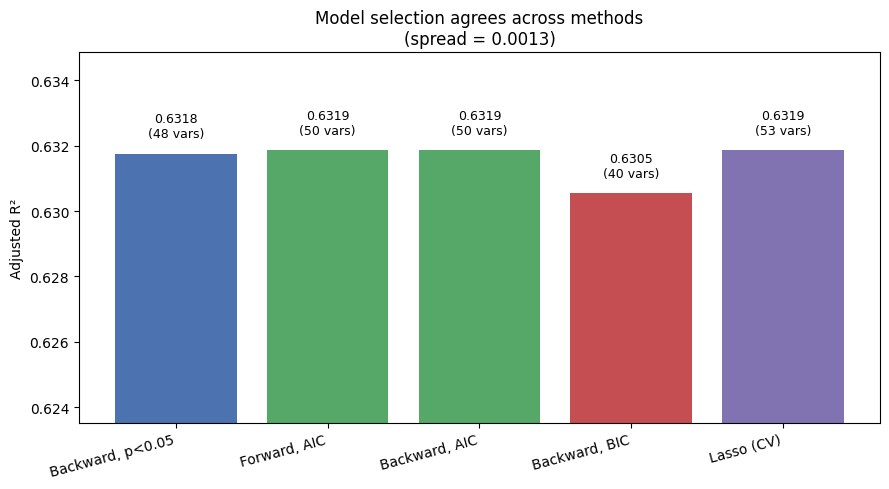

In [20]:
lasso_adj_r2 = fit_ols(lasso_idx).rsquared_adj

comparison_with_lasso = pd.concat([
    comparison,
    pd.DataFrame({"Method": ["Lasso (CV)"], "# Predictors": [len(lasso_idx)], "Adj R2": [lasso_adj_r2]})
], ignore_index=True)
display(comparison_with_lasso.round(4))

spread_with_lasso = comparison_with_lasso["Adj R2"].max() - comparison_with_lasso["Adj R2"].min()
print(f"Spread in Adjusted R2 across all 5 methods: {spread_with_lasso:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#4C72B0", "#55A868", "#55A868", "#C44E52", "#8172B2"]
bars = ax.bar(comparison_with_lasso["Method"], comparison_with_lasso["Adj R2"], color=colors)
for b, (_, row) in zip(bars, comparison_with_lasso.iterrows()):
    ax.text(b.get_x()+b.get_width()/2, row["Adj R2"]+0.0005, f"{row['Adj R2']:.4f}\n({row['# Predictors']} vars)",
            ha="center", fontsize=9)
ax.set_ylim(comparison_with_lasso["Adj R2"].min()-0.007, comparison_with_lasso["Adj R2"].max()+0.003)
ax.set_ylabel("Adjusted R²"); ax.set_title(f"Model selection agrees across methods\n(spread = {spread_with_lasso:.4f})")
plt.xticks(rotation=15, ha="right")
fig.tight_layout()
fig.savefig("chart6_model_comparison_with_lasso.png", dpi=150, bbox_inches="tight")
plt.show()

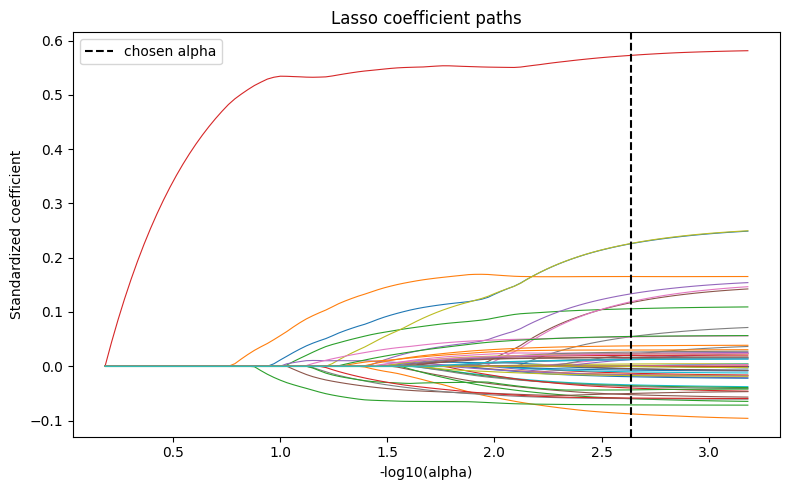

In [21]:
from sklearn.linear_model import lasso_path

alphas_path, coefs_path, _ = lasso_path(X_scaled, y, n_alphas=100)

fig, ax = plt.subplots(figsize=(8, 5))
for i in range(coefs_path.shape[0]):
    ax.plot(-np.log10(alphas_path), coefs_path[i], linewidth=0.8)
ax.axvline(-np.log10(lasso_cv.alpha_), color="black", linestyle="--", label=f"chosen alpha")
ax.set_xlabel("-log10(alpha)"); ax.set_ylabel("Standardized coefficient")
ax.set_title("Lasso coefficient paths")
ax.legend()
fig.tight_layout()
fig.savefig("chart7_lasso_path.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. VIF for the final model

,Variable,VIF
24,Rating_G - All Ages,4.334772
5,Type_Movie,4.327653
6,Type_OVA,4.050665
21,Rating_PG-13 - Teens 13 or older,3.950838
0,LN(Episodes),3.775078
8,Type_Music,3.379013
35,Genre_Hentai,3.134459
4,Type_Special,2.771993
3,LN(Members),2.471861
7,Type_ONA,2.223616


Max VIF: 4.33   Median VIF: 1.21


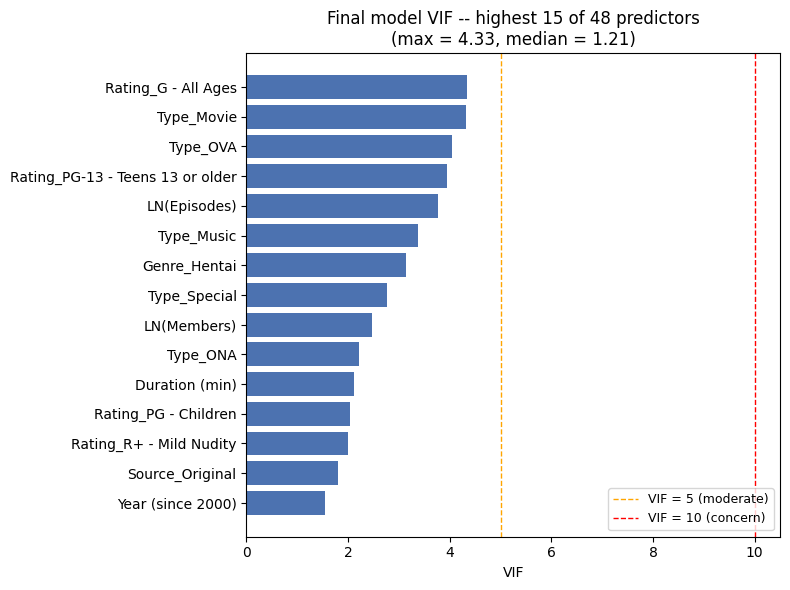

In [22]:
Xc_final = sm.add_constant(X_sig)
vif_table = pd.DataFrame({
    "Variable": [cols_order[i] for i in sig_idx],
    "VIF": [variance_inflation_factor(Xc_final, j) for j in range(1, Xc_final.shape[1])],
}).sort_values("VIF", ascending=False)
display(vif_table.head(10))
print(f"Max VIF: {vif_table['VIF'].max():.2f}   Median VIF: {vif_table['VIF'].median():.2f}")

top_vif = vif_table.sort_values("VIF", ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_vif["Variable"], top_vif["VIF"], color="#4C72B0")
ax.axvline(5, color="orange", linestyle="--", linewidth=1, label="VIF = 5 (moderate)")
ax.axvline(10, color="red", linestyle="--", linewidth=1, label="VIF = 10 (concern)")
ax.set_xlabel("VIF")
ax.set_title(f"Final model VIF -- highest 15 of {len(sig_idx)} predictors\n"
             f"(max = {vif_table['VIF'].max():.2f}, median = {vif_table['VIF'].median():.2f})")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig("chart5_final_vif.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Residual diagnostics on the final model

Checking the four classical OLS assumptions on `model_sig` (the backward
p-value model used as the final model). These aren't optional — every
p-value and CI reported elsewhere in this notebook depends on them holding
reasonably well.

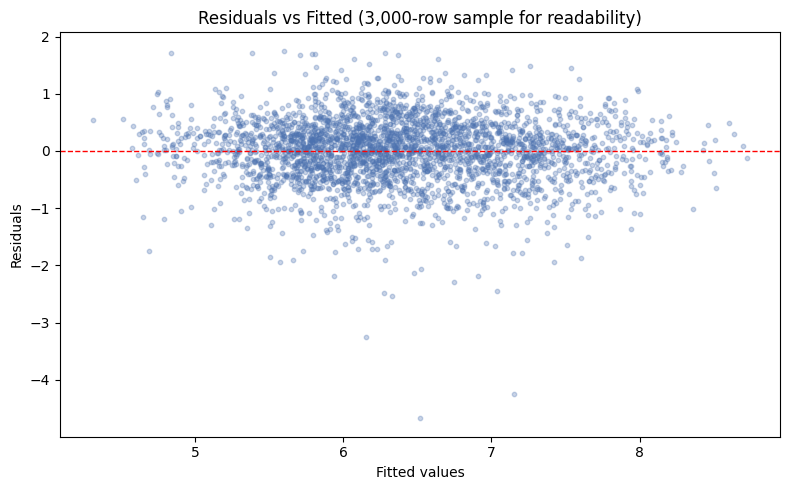

In [23]:
fitted = model_sig.fittedvalues
resid = model_sig.resid

fig, ax = plt.subplots(figsize=(8, 5))
sample_idx = np.random.RandomState(42).choice(len(fitted), size=min(3000, len(fitted)), replace=False)
ax.scatter(fitted.iloc[sample_idx] if hasattr(fitted, "iloc") else fitted[sample_idx],
           resid.iloc[sample_idx] if hasattr(resid, "iloc") else resid[sample_idx],
           alpha=0.3, s=10, color="#4C72B0")
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Fitted values"); ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Fitted (3,000-row sample for readability)")
fig.tight_layout()
fig.savefig("chart8_resid_vs_fitted.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = het_breuschpagan(model_sig.resid, model_sig.model.exog)
print(f"Breusch-Pagan LM stat: {bp_stat:.2f}   p-value: {bp_pvalue:.4g}")
print(f"Breusch-Pagan F stat:  {bp_fstat:.2f}   p-value: {bp_fpvalue:.4g}")
if bp_pvalue < 0.05:
    print("-> Evidence of heteroscedasticity (residual variance not constant).")
else:
    print("-> No strong evidence against constant variance.")

Breusch-Pagan LM stat: 478.16   p-value: 3.213e-72
Breusch-Pagan F stat:  10.24   p-value: 1.6e-73
-> Evidence of heteroscedasticity (residual variance not constant).


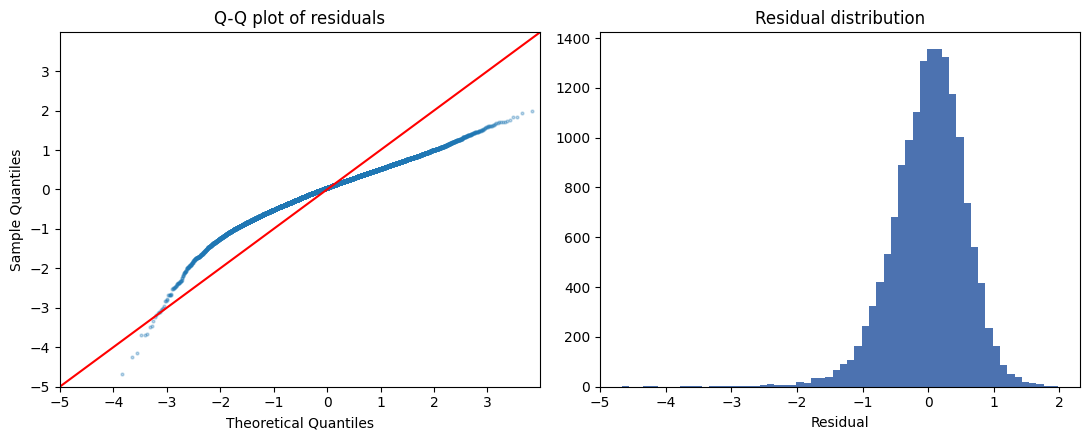

Jarque-Bera stat: 6233.92   p-value: 0
(Same caveat as Section 2: at this n, JB will reject near-exact normality too -- read the Q-Q plot's shape, especially the tails, over the p-value.)


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sm.qqplot(model_sig.resid, line="45", ax=axes[0], markersize=2, alpha=0.3)
axes[0].set_title("Q-Q plot of residuals")

axes[1].hist(model_sig.resid, bins=60, color="#4C72B0")
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Residual")

fig.tight_layout()
fig.savefig("chart9_resid_normality.png", dpi=150, bbox_inches="tight")
plt.show()

jb_stat, jb_p = stats.jarque_bera(model_sig.resid)
print(f"Jarque-Bera stat: {jb_stat:.2f}   p-value: {jb_p:.4g}")
print("(Same caveat as Section 2: at this n, JB will reject near-exact normality too -- "
      "read the Q-Q plot's shape, especially the tails, over the p-value.)")

Durbin-Watson statistic: 1.215  (2.0 = no autocorrelation; this only tests row-order autocorrelation, which is not really meaningful here since rows aren't time-ordered)


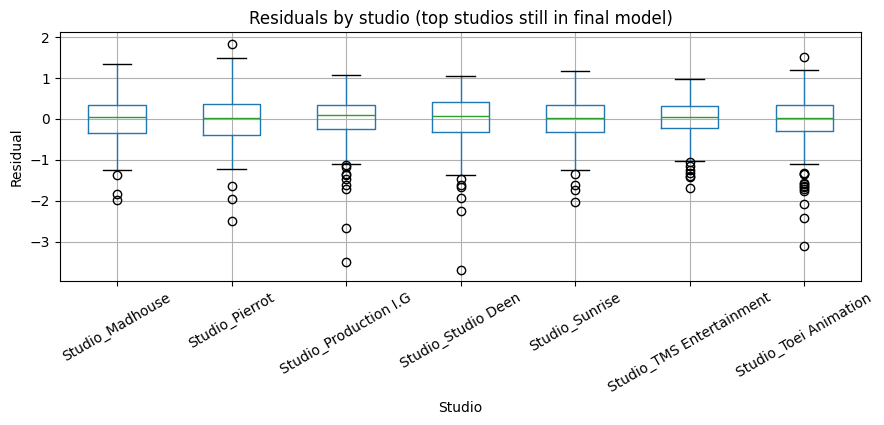

If any studio's box is clearly off-center from 0, residuals aren't independent of studio -- rows sharing a studio may be more similar to each other than OLS assumes.


In [26]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(model_sig.resid)
print(f"Durbin-Watson statistic: {dw:.3f}  (2.0 = no autocorrelation; this only tests row-order "
      "autocorrelation, which is not really meaningful here since rows aren't time-ordered)")

studio_cols = [cols_order[i] for i in sig_idx if cols_order[i].startswith("Studio_")]
if studio_cols:
    studio_resid = pd.DataFrame({"resid": model_sig.resid})
    for sc in studio_cols[:8]:
        col_idx = [cols_order[i] for i in sig_idx].index(sc)
        studio_resid[sc] = X_sig[:, col_idx]
    long = studio_resid.melt(id_vars="resid", var_name="Studio", value_name="is_member")
    long = long[long["is_member"] == 1]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    long.boxplot(column="resid", by="Studio", ax=ax, rot=30)
    ax.set_title("Residuals by studio (top studios still in final model)")
    ax.set_ylabel("Residual"); plt.suptitle("")
    fig.tight_layout()
    fig.savefig("chart10_resid_by_studio.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("If any studio's box is clearly off-center from 0, residuals aren't independent of studio "
          "-- rows sharing a studio may be more similar to each other than OLS assumes.")

Continuous predictors in final model: ['LN(Episodes)', 'Duration (min)', 'Year (since 2000)', 'LN(Members)']


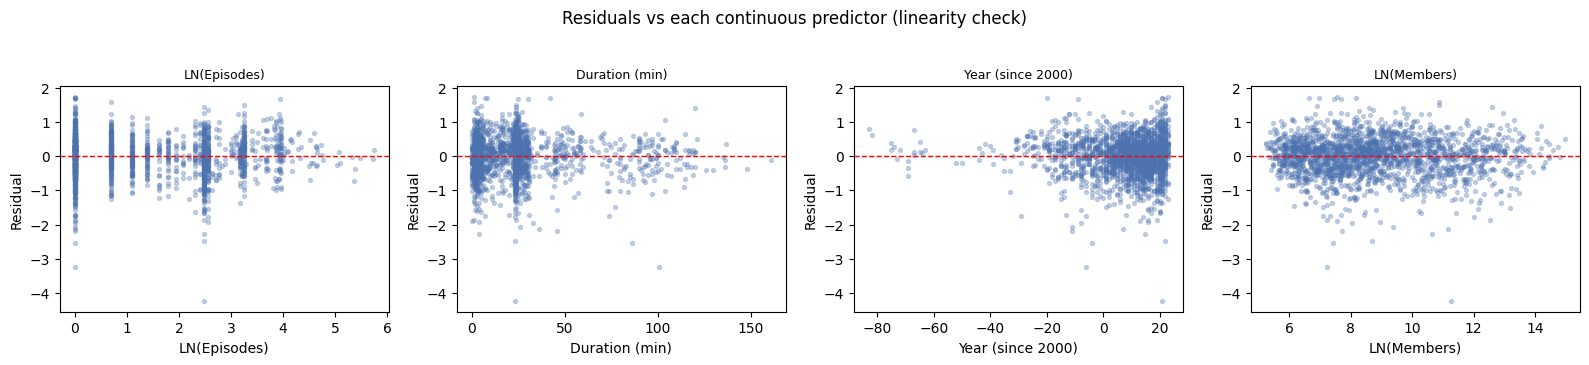

,Variable,Squared term p-value,AIC without,AIC with square
1,Duration (min),0.0000,26582.9983,26354.0269
0,LN(Episodes),0.0000,26582.9983,26522.8747
3,LN(Members),0.0000,26582.9983,26567.3766
2,Year (since 2000),0.0006,26582.9983,26573.0799


Rows with p < 0.05 AND lower AIC-with-square are candidates for adding a squared term and re-running variable selection with it included as a new candidate column.


In [27]:
continuous_final = [(j, cols_order[sig_idx[j]]) for j in range(len(sig_idx))
                     if len(np.unique(X_sig[:, j])) > 2]
print(f"Continuous predictors in final model: {[name for _, name in continuous_final]}")

n_cont = len(continuous_final)
fig, axes = plt.subplots(1, n_cont, figsize=(4*n_cont, 3.5))
if n_cont == 1:
    axes = [axes]
for ax, (j, name) in zip(axes, continuous_final):
    xvals = X_sig[:, j]
    sample_idx = np.random.RandomState(42).choice(len(xvals), size=min(2000, len(xvals)), replace=False)
    ax.scatter(xvals[sample_idx], model_sig.resid.values[sample_idx] if hasattr(model_sig.resid, "values") else model_sig.resid[sample_idx],
               alpha=0.3, s=8, color="#4C72B0")
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel(name); ax.set_ylabel("Residual")
fig.suptitle("Residuals vs each continuous predictor (linearity check)", y=1.03)
fig.tight_layout()
fig.savefig("chart11_resid_vs_continuous.png", dpi=150, bbox_inches="tight")
plt.show()

poly_rows = []
for j, name in continuous_final:
    X_poly = np.column_stack([X_sig, X_sig[:, j]**2])
    model_poly = sm.OLS(y, sm.add_constant(X_poly)).fit()
    sq_pval = model_poly.pvalues[-1]
    poly_rows.append({"Variable": name, "Squared term p-value": sq_pval,
                       "AIC without": model_sig.aic, "AIC with square": model_poly.aic})
poly_table = pd.DataFrame(poly_rows).sort_values("Squared term p-value")
display(poly_table.round(4))
print("Rows with p < 0.05 AND lower AIC-with-square are candidates for adding a squared term "
      "and re-running variable selection with it included as a new candidate column.")

## 13. Final coefficient table (Round 1 — superseded by Section 16)

In [28]:
coef_table = pd.DataFrame({
    "Variable": [cols_order[i] for i in sig_idx] + ["Intercept"],
    "Coefficient": list(model_sig.params[1:]) + [model_sig.params[0]],
    "Std Error": list(model_sig.bse[1:]) + [model_sig.bse[0]],
    "t-stat": list(model_sig.tvalues[1:]) + [model_sig.tvalues[0]],
    "p-value": list(model_sig.pvalues[1:]) + [model_sig.pvalues[0]],
})
display(coef_table.round(4))

coef_table.to_csv("final_model_coefficients.csv", index=False)
comparison.to_csv("model_comparison.csv", index=False)
vif_table.to_csv("vif_table.csv", index=False)
continuous_profile.to_csv("column_profile_continuous.csv", index=False)
binary_profile.to_csv("column_profile_binary.csv", index=False)
print("Saved all CSVs and charts to the working directory.")

,Variable,Coefficient,Std Error,t-stat,p-value
0,LN(Episodes),0.1838,0.0062,29.4933,0.0000
1,Duration (min),0.0066,0.0003,25.2172,0.0000
2,Year (since 2000),0.0077,0.0004,19.7292,0.0000
3,LN(Members),0.2811,0.0034,82.3525,0.0000
4,Type_Special,0.4823,0.0223,21.6481,0.0000
5,Type_Movie,0.4172,0.0257,16.2487,0.0000
6,Type_OVA,0.3862,0.0223,17.3504,0.0000
7,Type_ONA,0.2343,0.0204,11.4673,0.0000
8,Type_Music,0.8840,0.0283,31.2691,0.0000
9,Source_Visual novel,-0.1537,0.0218,-7.0518,0.0000


Saved all CSVs and charts to the working directory.


## 14. Round 2 — folding the linearity finding back into selection

Section 11 found real curvature for Duration and LN(Episodes) (squared-term
p < 0.0001 with meaningful AIC gains: -229 and -60 points respectively on a
base of 26,583), while LN(Members)² and Year² were technically significant
but negligible (-16 and -10 AIC) -- not worth the added complexity. Adding
the two squared terms as new candidates and rerunning selection from
scratch, since their presence can change which other predictors survive.
Both are mean-centered before squaring to avoid the squared term being
artificially collinear with its own linear term.

In [29]:
dur_idx = cols_order.index("Duration (min)")
ep_idx = cols_order.index("LN(Episodes)")

dur_c = X[:, dur_idx] - X[:, dur_idx].mean()
ep_c = X[:, ep_idx] - X[:, ep_idx].mean()

X2 = np.column_stack([X, dur_c**2, ep_c**2])
cols_order2 = cols_order + ["Duration (min) ^2 (centered)", "LN(Episodes) ^2 (centered)"]

def fit_ols2(idx):
    Xc = sm.add_constant(X2[:, idx]) if len(idx) else np.ones((X2.shape[0], 1))
    return sm.OLS(y, Xc).fit()

def backward_elimination_pvalue2(idx, alpha=0.05):
    idx = list(idx)
    while True:
        model = fit_ols2(idx)
        pvals = model.pvalues[1:]
        worst_i = int(np.argmax(pvals))
        if pvals[worst_i] > alpha:
            idx.pop(worst_i)
        else:
            return idx, model

full_idx2 = list(range(len(cols_order2)))
sig_idx2, model_sig2 = backward_elimination_pvalue2(full_idx2)

print(f"Round 2 model ({len(sig_idx2)} predictors): R2={model_sig2.rsquared:.4f}  "
      f"AdjR2={model_sig2.rsquared_adj:.4f}  F={model_sig2.fvalue:.2f}")
print(f"Round 1 (Section 7) had {len(sig_idx)} predictors, AdjR2={model_sig.rsquared_adj:.4f}")

kept_squares = [cols_order2[i] for i in sig_idx2 if "^2" in cols_order2[i]]
print(f"Squared terms retained: {kept_squares}")

r1_names, r2_names = set(cols_order[i] for i in sig_idx), set(cols_order2[i] for i in sig_idx2) - set(kept_squares)
print(f"Predictors dropped vs round 1: {sorted(r1_names - r2_names)}")
print(f"Predictors newly added vs round 1: {sorted(r2_names - r1_names)}")

Round 2 model (51 predictors): R2=0.6398  AdjR2=0.6386  F=544.76
Round 1 (Section 7) had 48 predictors, AdjR2=0.6318
Squared terms retained: ['Duration (min) ^2 (centered)', 'LN(Episodes) ^2 (centered)']
Predictors dropped vs round 1: []
Predictors newly added vs round 1: ['Genre_Romance']


In [30]:
Xc_final2 = sm.add_constant(X2[:, sig_idx2])
vif_table2 = pd.DataFrame({
    "Variable": [cols_order2[i] for i in sig_idx2],
    "VIF": [variance_inflation_factor(Xc_final2, j) for j in range(1, Xc_final2.shape[1])],
}).sort_values("VIF", ascending=False)
display(vif_table2.head(10))
print(f"Max VIF: {vif_table2['VIF'].max():.2f}   Median VIF: {vif_table2['VIF'].median():.2f}")

,Variable,VIF
1,Duration (min),6.032797
0,LN(Episodes),5.227878
49,Duration (min) ^2 (centered),4.583225
5,Type_Movie,4.469611
24,Rating_G - All Ages,4.405364
6,Type_OVA,4.072467
21,Rating_PG-13 - Teens 13 or older,3.987786
8,Type_Music,3.627253
35,Genre_Hentai,3.149336
4,Type_Special,2.876761


Max VIF: 6.03   Median VIF: 1.22


In [31]:
bp_stat2, bp_p2, bp_f2, bp_fp2 = het_breuschpagan(model_sig2.resid, model_sig2.model.exog)
print(f"Round 1 Breusch-Pagan: stat=478.16  p=3.2e-72")
print(f"Round 2 Breusch-Pagan: stat={bp_stat2:.2f}  p={bp_p2:.4g}")
print("The stat rose rather than fell. Breusch-Pagan tests whether residual variance depends on the "
      "predictors, a different question from whether the mean function is correctly shaped -- fixing "
      "the curvature in Duration/Episodes doesn't guarantee it fixes variance too. A follow-up check "
      "(regressing squared residuals on each predictor) shows the signal is diffuse: several Type/Genre/"
      "Rating dummies (e.g. Type_Special, Genre_Horror, Rating_G) carry as much signal as the squared "
      "terms, and Duration/LN(Episodes) were already linked to residual variance in their linear form "
      "before being squared. This looks structural (subgroup variance differences), not caused by the "
      "curvature fix -- which is why HC3 robust SEs are applied below regardless of the BP result.")

Round 1 Breusch-Pagan: stat=478.16  p=3.2e-72
Round 2 Breusch-Pagan: stat=570.52  p=6.551e-89
The stat rose rather than fell. Breusch-Pagan tests whether residual variance depends on the predictors, a different question from whether the mean function is correctly shaped -- fixing the curvature in Duration/Episodes doesn't guarantee it fixes variance too. A follow-up check (regressing squared residuals on each predictor) shows the signal is diffuse: several Type/Genre/Rating dummies (e.g. Type_Special, Genre_Horror, Rating_G) carry as much signal as the squared terms, and Duration/LN(Episodes) were already linked to residual variance in their linear form before being squared. This looks structural (subgroup variance differences), not caused by the curvature fix -- which is why HC3 robust SEs are applied below regardless of the BP result.


## 15. What's actually driving the heteroscedasticity

Breusch-Pagan flags *that* variance is uneven, but not *which* variables
are responsible. Regressing squared residuals directly on each predictor
(the same mechanic BP uses internally) ranks the contributors individually.

In [32]:
resid_sq2 = model_sig2.resid ** 2
aux_df = pd.DataFrame(X2[:, sig_idx2], columns=[cols_order2[i] for i in sig_idx2])
aux_df = sm.add_constant(aux_df)
aux_model = sm.OLS(resid_sq2, aux_df).fit()

aux_ranked = aux_model.params[1:].to_frame("coef")
aux_ranked["abs_t"] = aux_model.tvalues[1:].abs()
aux_ranked = aux_ranked.sort_values("abs_t", ascending=False)

print("Top drivers of residual variance (not just the squared terms):")
display(aux_ranked.head(15))
print("\nYear does not appear in the top 15 -- the earlier 'Year fan-out' guess was wrong. "
      "The signal is diffuse across Type/Genre/Rating category dummies, plus Duration and "
      "LN(Episodes) in BOTH their linear and squared form -- meaning these two were already "
      "tied to residual variance before being squared, not because of the squaring itself.")

Top drivers of residual variance (not just the squared terms):


,coef,abs_t
Type_Special,-0.234141,8.745790
LN(Episodes),-0.073017,8.437631
Genre_Horror,0.258452,7.618735
Rating_G - All Ages,-0.182756,7.088983
Duration (min),-0.003627,7.011365
LN(Episodes) ^2 (centered),0.021188,6.471147
Duration (min) ^2 (centered),0.000044,6.210327
LN(Members),0.024342,5.968536
Type_Movie,-0.167956,5.455888
Type_Music,-0.174107,5.038862



Year does not appear in the top 15 -- the earlier 'Year fan-out' guess was wrong. The signal is diffuse across Type/Genre/Rating category dummies, plus Duration and LN(Episodes) in BOTH their linear and squared form -- meaning these two were already tied to residual variance before being squared, not because of the squaring itself.


In [33]:
model_final_robust = model_sig2.get_robustcov_results(cov_type="HC3")
print(model_final_robust.summary())
print("\nCompare model_sig2.bse (regular SE) vs model_final_robust.bse (HC3) -- "
      "coefficients are unchanged, only standard errors/p-values differ.")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     610.5
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:07:51   Log-Likelihood:                -13093.
No. Observations:               15692   AIC:                         2.629e+04
Df Residuals:                   15640   BIC:                         2.669e+04
Df Model:                          51                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1066      0.048     64.899      0.0

In [34]:
compare_se = pd.DataFrame({
    "Variable": ["const"] + [cols_order2[i] for i in sig_idx2],
    "Coef": model_sig2.params,
    "SE (OLS)": model_sig2.bse,
    "p (OLS)": model_sig2.pvalues,
    "SE (HC3)": model_final_robust.bse,
    "p (HC3)": model_final_robust.pvalues,
})
compare_se["Sig flip (0.05)"] = (compare_se["p (OLS)"] < 0.05) != (compare_se["p (HC3)"] < 0.05)

flips = compare_se[compare_se["Sig flip (0.05)"]]
print(f"{len(flips)} of {len(compare_se)} predictors flip significance status under HC3 vs. naive OLS SEs")
if len(flips):
    display(flips)
else:
    print("No flips -- heteroscedasticity is real but wasn't distorting which predictors you'd call significant.")

0 of 52 predictors flip significance status under HC3 vs. naive OLS SEs
No flips -- heteroscedasticity is real but wasn't distorting which predictors you'd call significant.


In [35]:
model_hc1 = model_sig2.get_robustcov_results(cov_type="HC1")
se_variants = pd.DataFrame({
    "Variable": ["const"] + [cols_order2[i] for i in sig_idx2],
    "SE (HC1)": model_hc1.bse,
    "SE (HC3)": model_final_robust.bse,
})
se_variants["% diff"] = (se_variants["SE (HC3)"] - se_variants["SE (HC1)"]) / se_variants["SE (HC1)"] * 100
display(se_variants.reindex(se_variants["% diff"].abs().sort_values(ascending=False).index).head(10))

,Variable,SE (HC1),SE (HC3),% diff
16,Source_Web novel,0.082006,0.083858,2.257739
34,Genre_Erotica,0.099072,0.101287,2.234934
19,Source_Card game,0.056170,0.057000,1.479111
51,LN(Episodes) ^2 (centered),0.003597,0.003640,1.202890
35,Genre_Girls Love,0.057341,0.057995,1.140471
30,Genre_Boys Love,0.061609,0.062233,1.012658
18,Source_Mixed media,0.061820,0.062348,0.854510
29,Genre_Award Winning,0.034251,0.034466,0.628171
50,Duration (min) ^2 (centered),0.000007,0.000007,0.556193
48,Studio_Studio Deen,0.036868,0.037061,0.522868


### Outlier check — worst-fit titles


In [36]:
resid_final = model_sig2.resid
worst = pd.DataFrame({
    "Display Name": d["Display Name"].values,
    "Actual Score": y,
    "Predicted": model_sig2.fittedvalues,
    "Residual": resid_final,
}).sort_values("Residual").head(25)
display(worst)

,Display Name,Actual Score,Predicted,Residual
12700,"Tenkuu Danzai Skelter+Heaven (OVA, 2004)",1.85,6.531557,-4.681557
12690,"Ex-Arm (TV, winter 2021)",2.90,7.147473,-4.247473
12698,"Hametsu no Mars (OVA, 2005)",2.22,6.378238,-4.158238
13642,"Tsui no Sora (OVA, 2002)",2.22,5.926217,-3.706217
12699,"Utsu Musume Sayuri (OVA, 2003)",1.98,5.586383,-3.606383
12671,"Pupa (TV, winter 2014)",3.29,6.833470,-3.543470
12688,"Shitcom (ONA, 2012)",2.76,6.169318,-3.409318
12696,"Abunai Sisters: Koko & Mika (OVA, 2009)",2.53,5.879075,-3.349075
12673,"Vampire Holmes (TV, spring 2015)",3.28,6.472314,-3.192314
12691,"Super Child (Movie, 1994)",2.91,6.078043,-3.168043


## 16. Updated final coefficient table (post round 2 — FINAL MODEL)

In [37]:
coef_table = pd.DataFrame({
    "Variable": [cols_order2[i] for i in sig_idx2] + ["Intercept"],
    "Coefficient": list(model_sig2.params[1:]) + [model_sig2.params[0]],
    "Std Error": list(model_sig2.bse[1:]) + [model_sig2.bse[0]],
    "t-stat": list(model_sig2.tvalues[1:]) + [model_sig2.tvalues[0]],
    "p-value": list(model_sig2.pvalues[1:]) + [model_sig2.pvalues[0]],
})
display(coef_table.round(4))

coef_table.to_csv("final_model_coefficients.csv", index=False)
comparison.to_csv("model_comparison.csv", index=False)
vif_table.to_csv("vif_table.csv", index=False)
continuous_profile.to_csv("column_profile_continuous.csv", index=False)
binary_profile.to_csv("column_profile_binary.csv", index=False)
print("Saved all CSVs and charts to the working directory.")

,Variable,Coefficient,Std Error,t-stat,p-value
0,LN(Episodes),0.1575,0.0073,21.6721,0.0000
1,Duration (min),0.0117,0.0004,26.9072,0.0000
2,Year (since 2000),0.0086,0.0004,21.9624,0.0000
3,LN(Members),0.2818,0.0034,82.2715,0.0000
4,Type_Special,0.5197,0.0225,23.1197,0.0000
5,Type_Movie,0.4527,0.0259,17.5115,0.0000
6,Type_OVA,0.3588,0.0221,16.2279,0.0000
7,Type_ONA,0.3026,0.0208,14.5343,0.0000
8,Type_Music,0.9519,0.0290,32.8084,0.0000
9,Source_Visual novel,-0.1486,0.0216,-6.8633,0.0000


Saved all CSVs and charts to the working directory.
